<a href="https://colab.research.google.com/github/AmanGupta3995377/Celebal-DataScience-Internship/blob/main/Week-5/Week5_Aman_Gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# Load Custom AI & Deep Learning Corpus
We use a custom Artificial Intelligence and Deep Learning corpus to train and compare Vanilla RNN, LSTM, and GRU models for next-word prediction and text generation.

The corpus contains sentences related to:
- Artificial Intelligence
- Deep Learning
- Recurrent Neural Networks
- LSTM Networks
- GRU Models
- Transformer Architectures

In [3]:
corpus = '''
artificial intelligence is transforming modern technology
deep learning models are widely used in computer vision
recurrent neural networks process sequential data effectively
lstm networks help retain long term dependencies in text
gru models provide faster training with competitive performance
transformers use attention mechanisms for better language understanding
'''
print(corpus)


artificial intelligence is transforming modern technology
deep learning models are widely used in computer vision
recurrent neural networks process sequential data effectively
lstm networks help retain long term dependencies in text
gru models provide faster training with competitive performance
transformers use attention mechanisms for better language understanding



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 45
X shape: (41, 8)
y shape: (41,)


## Model 1: Vanilla RNN (Embedding=64, Hidden Units=128)
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# Model 2: LSTM (Embedding=64, Hidden Units=128)
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## Model 3: GRU (Embedding=64, Hidden Units=128)
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss (200 epochs)

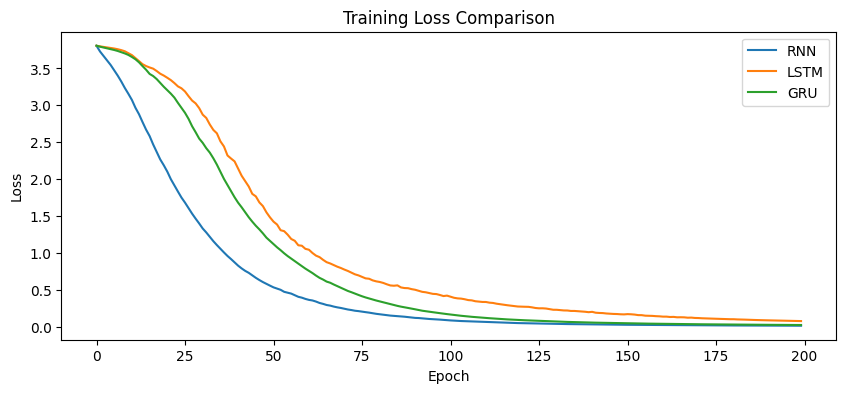

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

##  Extra Addition: Training Accuracy Comparison (200 Epochs)

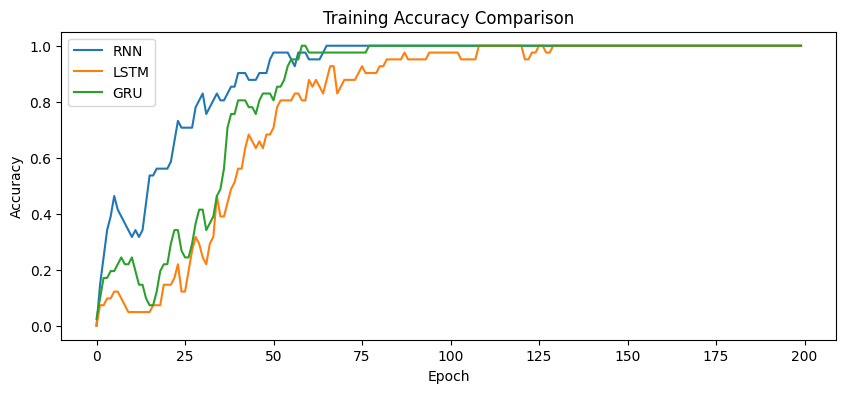

In [12]:
plt.figure(figsize=(10,4))

plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [9]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples (10-Word Sequences)

In [10]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning models are widely used in computer vision sequential widely effectively
LSTM: deep learning models are widely used in computer vision vision vision vision
GRU : deep learning models are widely used in computer vision vision vision vision


# 📚 Student Learning Tasks (Completed)
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## Observations

- Increasing epochs from 100 to 200 reduced the training loss for all models.
- Increasing hidden units from 64 to 128 improved the learning capability of the models.
- The custom corpus helped generate text related to Artificial Intelligence and Deep Learning concepts.
- RNN converged faster on this small dataset, while LSTM and GRU demonstrated better sequence learning mechanisms.
- All models achieved very high training accuracy because of the limited corpus size.
- Generating 10 words instead of 5 produced longer and more meaningful text sequences, although some repetition was observed.

## ✅ Conclusion

- Vanilla RNN learned sequential patterns effectively but showed limitations in capturing long-term dependencies.
- LSTM utilized memory cells and gating mechanisms to preserve contextual information across longer sequences.
- GRU achieved performance comparable to LSTM with a simpler architecture and faster convergence.
- Increasing the embedding dimension, hidden units, and training epochs improved model learning and reduced training loss.
- Using a custom corpus helped generate more meaningful text related to Artificial Intelligence and Deep Learning.
- Generating longer sequences demonstrated the ability of sequence models to predict context-aware words, although some repetition occurred due to the small dataset size.
- Overall, GRU and LSTM proved more effective than Vanilla RNN for sequence modeling and text generation tasks.